# Flight Price Prediction using Machine Learning

**Problem:** Regression  
**Target:** `price`  
**Dataset:** Airlines Flights Data  

Notebook ini berisi EDA, preprocessing, setup eksperimen, model training, model evaluation, dan penyimpanan model untuk deployment Streamlit.

## 1. Import Library

Library yang digunakan mencakup pandas untuk pengolahan data, matplotlib untuk visualisasi, dan scikit-learn untuk pemodelan machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Dataset

Pada Google Colab, unggah file `airlines_flights_data.csv`, lalu jalankan sel berikut.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Jika file sudah ada di direktori Colab
DATA_PATH = "/content/drive/MyDrive/Digital Skola/Final Project/Final Project DS/Kel2_DS60_Final_Project_Airline_Regression/data/airlines_flights_data.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


## 3. Exploratory Data Analysis

EDA dilakukan untuk memahami struktur data, tipe variabel, nilai kosong, duplikasi, distribusi target, dan pola hubungan antar fitur dengan harga tiket.

In [6]:
print("Shape dataset:", df.shape)
print("\nInfo dataset:")
print(df.info())
print("\nMissing values:")
print(df.isna().sum())
print("\nJumlah data duplikat:", df.duplicated().sum())

df.describe(include="all").T

Shape dataset: (300153, 12)

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB
None

Missing values:
index               0
airline             0
flight              0
source_city         0
d

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,300153.0,NaN,NaN,NaN,150076.0,86646.852011,0.0,75038.0,150076.0,225114.0,300152.0
airline,300153,6,Vistara,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flight,300153,1561,UK-706,3235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_city,300153,6,Delhi,61343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departure_time,300153,6,Morning,71146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stops,300153,3,one,250863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_time,300153,6,Night,91538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_city,300153,6,Mumbai,59097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,300153,2,Economy,206666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,300153.0,NaN,NaN,NaN,12.221021,7.191997,0.83,6.83,11.25,16.17,49.83


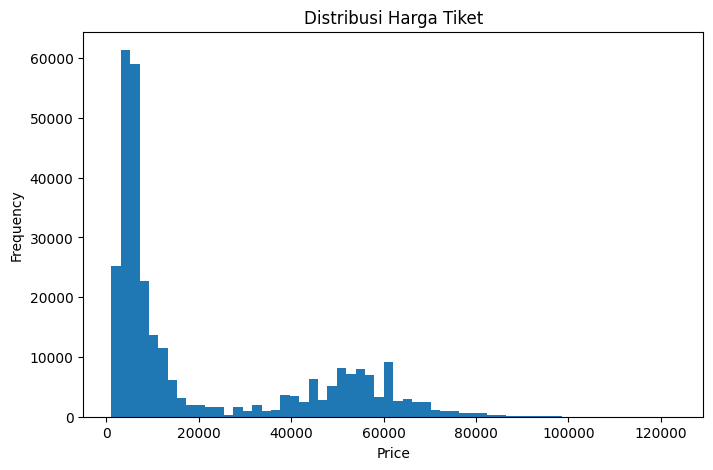

Minimum price: 1105
Median price: 7425.0
Mean price: 20889.66
Maximum price: 123071


In [7]:
# Distribusi target price
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=60)
plt.title("Distribusi Harga Tiket")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

print("Minimum price:", df["price"].min())
print("Median price:", df["price"].median())
print("Mean price:", round(df["price"].mean(), 2))
print("Maximum price:", df["price"].max())

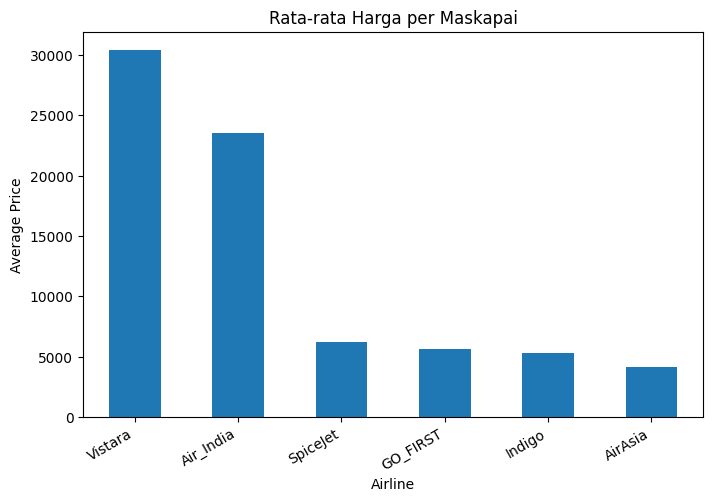

,price
airline,
Vistara,30396.536302
Air_India,23507.019112
SpiceJet,6179.278881
GO_FIRST,5652.007595
Indigo,5324.216303
AirAsia,4091.072742


In [8]:
# Rata-rata harga berdasarkan maskapai
avg_airline = df.groupby("airline")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
avg_airline.plot(kind="bar")
plt.title("Rata-rata Harga per Maskapai")
plt.xlabel("Airline")
plt.ylabel("Average Price")
plt.xticks(rotation=30, ha="right")
plt.show()

avg_airline

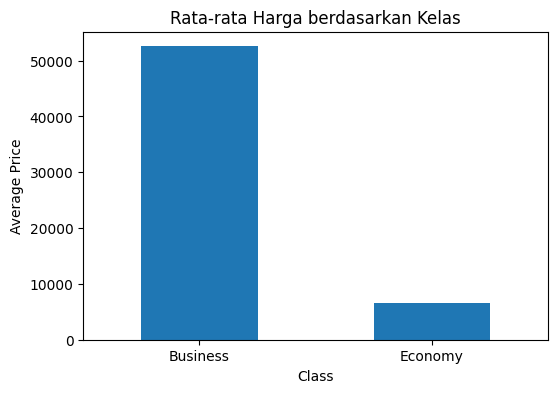

,price
class,
Business,52540.081124
Economy,6572.342383


In [9]:
# Rata-rata harga berdasarkan kelas penerbangan
avg_class = df.groupby("class")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
avg_class.plot(kind="bar")
plt.title("Rata-rata Harga berdasarkan Kelas")
plt.xlabel("Class")
plt.ylabel("Average Price")
plt.xticks(rotation=0)
plt.show()

avg_class

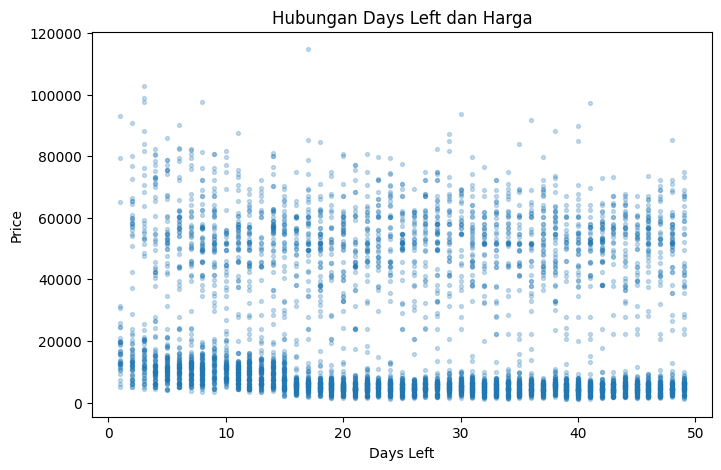

In [10]:
# Hubungan days_left dan price
sample_df = df.sample(n=min(6000, len(df)), random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(sample_df["days_left"], sample_df["price"], s=8, alpha=0.25)
plt.title("Hubungan Days Left dan Harga")
plt.xlabel("Days Left")
plt.ylabel("Price")
plt.show()

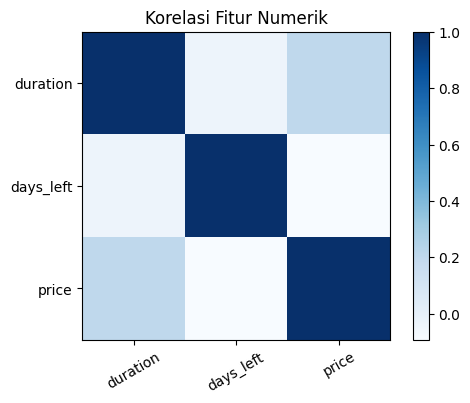

,duration,days_left,price
duration,1.000000,-0.039157,0.204222
days_left,-0.039157,1.000000,-0.091949
price,0.204222,-0.091949,1.000000


In [11]:
# Korelasi fitur numerik
numeric_corr = df[["duration", "days_left", "price"]].corr()

plt.figure(figsize=(6, 4))
plt.imshow(numeric_corr, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(numeric_corr.columns)), numeric_corr.columns, rotation=30)
plt.yticks(range(len(numeric_corr.columns)), numeric_corr.columns)
plt.title("Korelasi Fitur Numerik")
plt.show()

numeric_corr

### Insight EDA

1. Dataset berisi 300.153 baris dan 12 kolom.
2. Tidak ditemukan missing value pada dataset.
3. Target `price` memiliki rentang nilai yang lebar sehingga problem sesuai untuk regresi.
4. Kelas penerbangan Business memiliki rata-rata harga jauh lebih tinggi dibanding Economy.
5. Variabel `days_left` penting karena harga cenderung berubah berdasarkan jarak waktu menuju keberangkatan.
6. Kolom `index` tidak digunakan karena hanya penanda baris.
7. Kolom `flight` tidak digunakan karena memiliki kardinalitas tinggi dan berisiko membuat model terlalu bergantung pada kode penerbangan tertentu.

## 4. Data Preprocessing

Tahap preprocessing mencakup pemilihan fitur, pemisahan fitur dan target, train-test split, encoding fitur kategorikal, dan scaling fitur numerik.

In [12]:
# Drop kolom yang tidak digunakan
X = df.drop(columns=["price", "index", "flight"])
y = df["price"]

categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Categorical features: ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']
Numeric features: ['duration', 'days_left']
Train shape: (240122, 9)
Test shape: (60031, 9)


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

## 5. Setup Eksperimen Modelling

Eksperimen memakai dua model pembanding:

1. **Ridge Regression** sebagai baseline linear model.
2. **Decision Tree Regressor** sebagai model non-linear yang mampu menangkap pola kategorikal dan interaksi antar fitur.

Evaluasi menggunakan MAE, RMSE, R², dan MAPE.

In [15]:
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 1))) * 100
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_%": mape
    }

experiments = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=20, min_samples_leaf=4, random_state=42)
}

results = []
trained_models = {}

for name, estimator in experiments.items():
    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", estimator)
    ])
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    results.append(evaluate_model(name, pipeline, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,model,MAE,RMSE,R2,MAPE_%
1,Decision Tree,1433.359407,3208.01265,0.980036,10.139216
0,Ridge Regression,4553.225111,6761.71910,0.911305,46.239996


## 6. Model Evaluation

Model terbaik dipilih berdasarkan RMSE paling rendah dan R² paling tinggi. RMSE menunjukkan rata-rata besar kesalahan prediksi dalam satuan harga. R² menunjukkan kemampuan model menjelaskan variasi harga tiket.

In [16]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

y_pred = best_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))
print("MAPE (%):", np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 1))) * 100)

Best model: Decision Tree
MAE: 1433.3594069148542
RMSE: 3208.0126500133747
R2: 0.9800355013347111
MAPE (%): 10.139216421211477


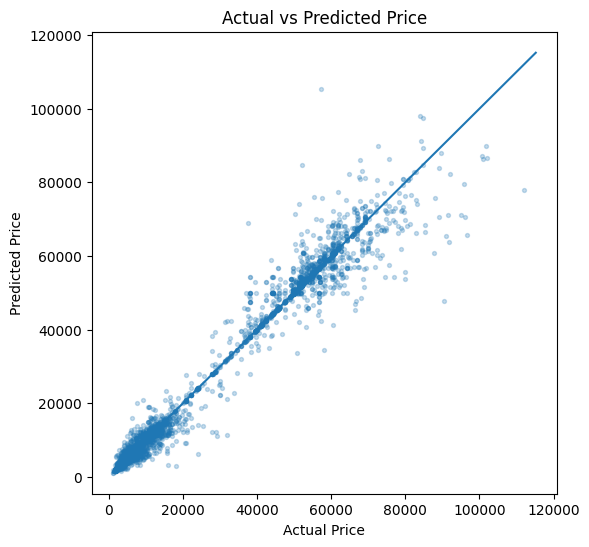

In [17]:
# Visualisasi actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test.sample(5000, random_state=42), pd.Series(y_pred, index=y_test.index).sample(5000, random_state=42), s=8, alpha=0.25)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.title("Actual vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

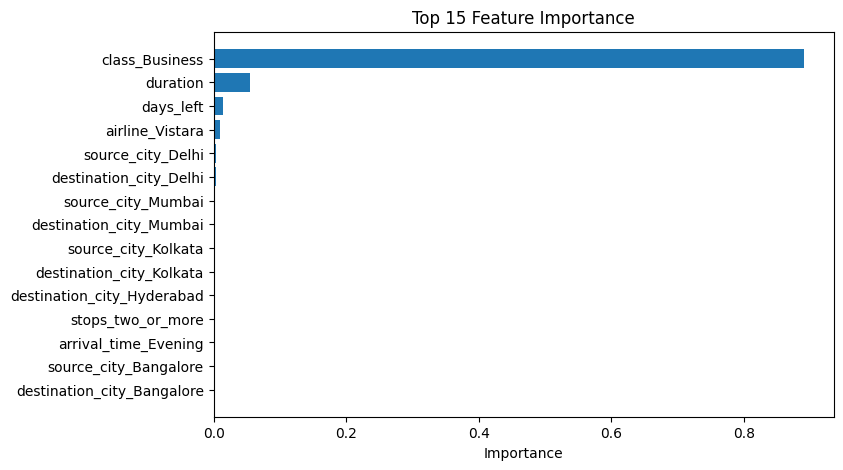

,feature,importance
33,class_Business,0.890404
35,duration,0.054253
36,days_left,0.013927
5,airline_Vistara,0.009414
8,source_city_Delhi,0.004009
29,destination_city_Delhi,0.003496
11,source_city_Mumbai,0.002364
32,destination_city_Mumbai,0.001886
10,source_city_Kolkata,0.001541
31,destination_city_Kolkata,0.001518


In [18]:
# Feature importance untuk Decision Tree
if best_model_name == "Decision Tree":
    ohe = best_model.named_steps["preprocess"].named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(categorical_features).tolist()
    feature_names = cat_names + numeric_features
    importances = best_model.named_steps["model"].feature_importances_

    fi = pd.DataFrame({"feature": feature_names, "importance": importances})
    fi = fi.sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(8, 5))
    plt.barh(fi["feature"][::-1], fi["importance"][::-1])
    plt.title("Top 15 Feature Importance")
    plt.xlabel("Importance")
    plt.show()

    display(fi)

## 7. Save Model untuk Deployment

Model terbaik disimpan dalam format `.pkl` agar dapat digunakan kembali pada aplikasi Streamlit.

In [19]:
joblib.dump(best_model, "flight_price_model.pkl")

metadata = {
    "target": "price",
    "dropped_columns": ["index", "flight"],
    "features": X.columns.tolist(),
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "best_model": best_model_name,
    "results": results_df.to_dict(orient="records")
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Model dan metadata berhasil disimpan.")

Model dan metadata berhasil disimpan.


## 8. Kesimpulan

Decision Tree Regressor menjadi model terbaik pada eksperimen ini karena menghasilkan nilai RMSE lebih rendah dan R² lebih tinggi dibanding Ridge Regression. Model mampu menangkap pola non-linear dari fitur kategorikal dan numerik. Model ini kemudian digunakan sebagai model utama pada aplikasi Streamlit untuk memprediksi harga tiket baru.